In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\rohit\Downloads\Retail_Sales_400_Records.csv")

In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       400 non-null    object 
 1   Order Date     400 non-null    object 
 2   Customer ID    400 non-null    object 
 3   Customer Name  400 non-null    object 
 4   Segment        400 non-null    object 
 5   Region         400 non-null    object 
 6   State          400 non-null    object 
 7   Category       400 non-null    object 
 8   Sub-Category   400 non-null    object 
 9   Product Name   400 non-null    object 
 10  Sales          400 non-null    float64
 11  Quantity       400 non-null    int64  
 12  Discount       400 non-null    float64
 13  Profit         400 non-null    float64
dtypes: float64(3), int64(1), object(10)
memory usage: 43.9+ KB


In [4]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer ID      0
Customer Name    0
Segment          0
Region           0
State            0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df.describe()

,Sales,Quantity,Discount,Profit
count,400.000000,400.000000,400.000000,400.000000
mean,1007.359975,5.312500,0.126500,132.412875
std,578.631075,2.780138,0.100613,140.453071
min,29.570000,1.000000,0.000000,-72.880000
25%,518.715000,3.000000,0.050000,23.115000
50%,969.130000,5.000000,0.100000,92.655000
75%,1541.807500,8.000000,0.200000,208.435000
max,1994.900000,10.000000,0.300000,590.980000


In [6]:
numerical_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]
print(numerical_df.corr())

             Sales  Quantity  Discount    Profit
Sales     1.000000 -0.025850 -0.023826  0.539935
Quantity -0.025850  1.000000 -0.042224 -0.056978
Discount -0.023826 -0.042224  1.000000 -0.113043
Profit    0.539935 -0.056978 -0.113043  1.000000


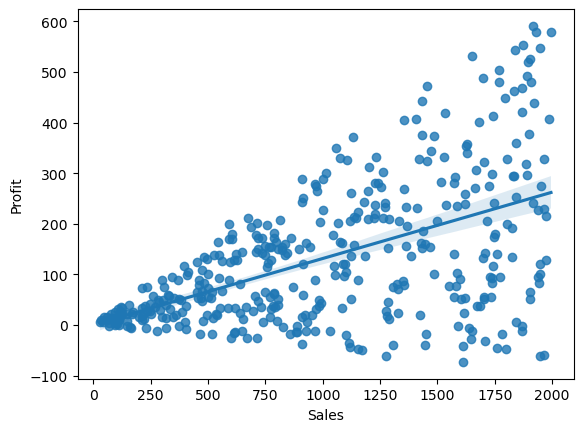

In [7]:
sns.regplot(x="Sales", y="Profit", data=df)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

In [9]:
X = df[['Sales', 'Quantity', 'Discount']]
y = df['Profit']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test) 

In [12]:
pickle.dump(scaler, open('scaling.pkl', 'wb'))

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [15]:
reg_pred = regression.predict(X_test)

In [16]:
print("MAE:", mean_absolute_error(y_test, reg_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, reg_pred)))
print("R2 Score:", r2_score(y_test, reg_pred))

MAE: 89.15567362730954
RMSE: 114.788441857555
R2 Score: 0.31792995159568693


In [17]:
pickle.dump(regression, open('regmodel.pkl', 'wb'))

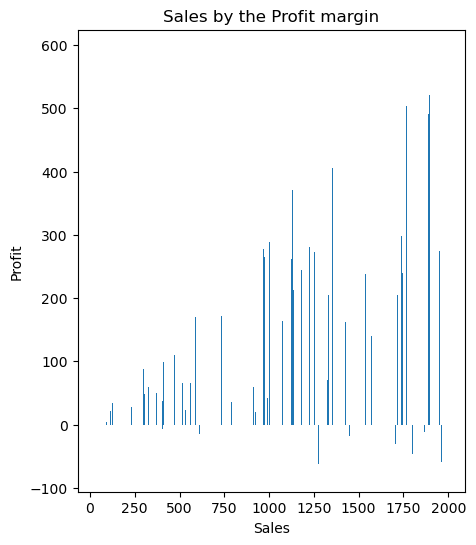

In [25]:
plt.figure(figsize=(5,6))
plt.bar(df["Sales"],df["Profit"])
plt.title('Sales by the Profit margin')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

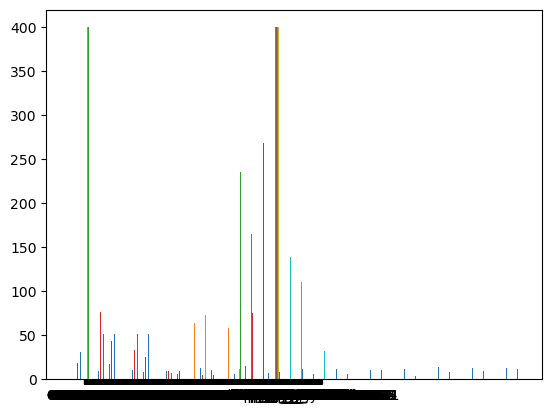

In [28]:
plt.hist(df,bins=40)
plt.show()

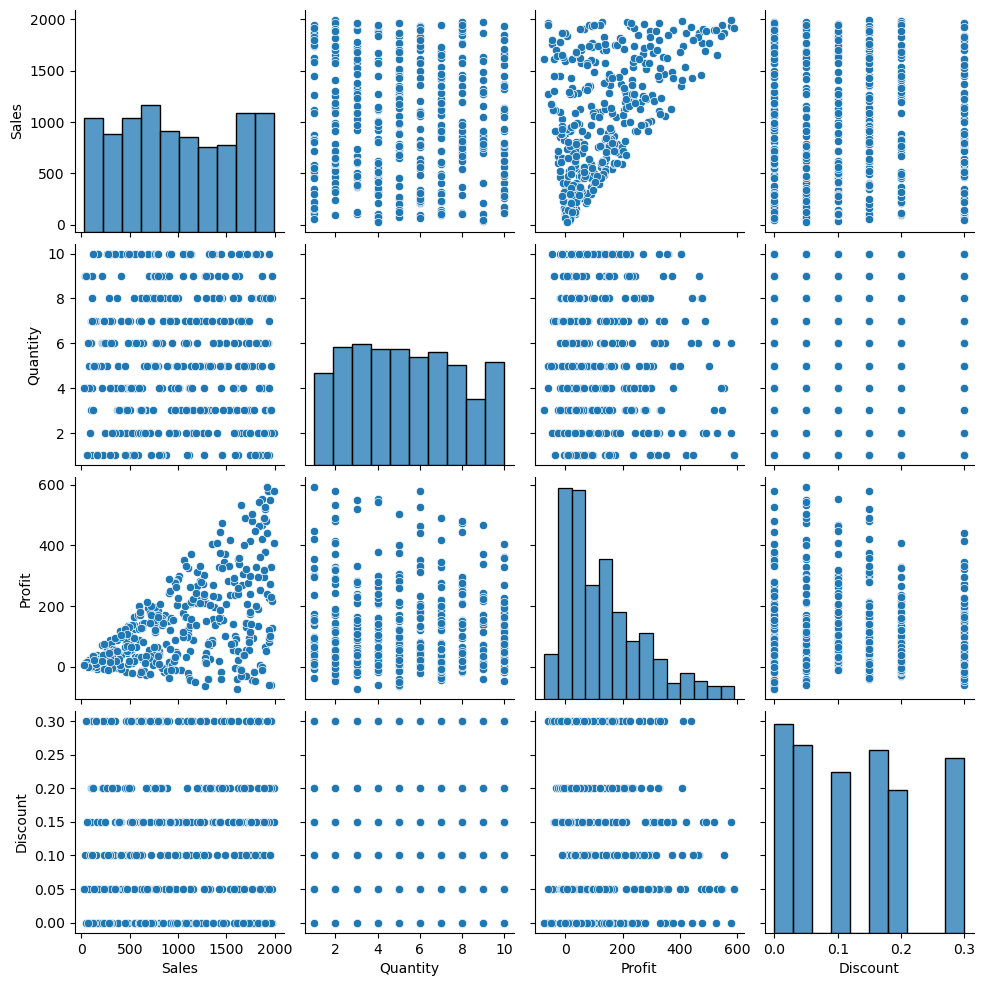

In [30]:
sns.pairplot(df[['Sales','Quantity','Profit','Discount']])
plt.show()